# LeetCode #605: Can Place Flowers

https://leetcode.com/problems/can-place-flowers/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(2^k)$ | $O(k)$ |
| **Optimal: Greedy Scan** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Try every subset of empty plots as candidate planting positions, check validity for each. With $k$ empty plots there are $2^k$ subsets — completely intractable for large inputs.

### Optimal: Greedy Scan ★
Walk left-to-right. At each index, if the current plot is empty (0) and both its neighbours are also 0 (treat out-of-bounds as 0), plant there immediately and increment a counter. Greedy is safe because planting as early as possible never blocks a later plant that would have been planted earlier.

**Why this is better than brute force:** One pass, O(1) space — no recursion, no backtracking.

**Constraints:**
* `1 <= flowerbed.length <= 2 * 10^4`
* `flowerbed[i]` is `0` or `1`
* There are no two adjacent flowers in the input.
* `0 <= n <= flowerbed.length`

## Solutions

### C#

In [ ]:
public class Solution {
    public bool CanPlaceFlowers(int[] flowerbed, int n) {
        int count = 0;
        for (int i = 0; i < flowerbed.Length; i++) {
            // Only consider empty plots
            if (flowerbed[i] == 0) {
                bool leftEmpty  = (i == 0 || flowerbed[i - 1] == 0);
                bool rightEmpty = (i == flowerbed.Length - 1 || flowerbed[i + 1] == 0);
                // Plant greedily when both neighbours are clear
                if (leftEmpty && rightEmpty) {
                    flowerbed[i] = 1;
                    count++;
                }
            }
        }
        return count >= n;
    }
}

### Python

In [ ]:
class Solution:
    def canPlaceFlowers(self, flowerbed: list[int], n: int) -> bool:
        count = 0
        for i in range(len(flowerbed)):
            # Only consider empty plots
            if flowerbed[i] == 0:
                left_empty  = (i == 0 or flowerbed[i - 1] == 0)
                right_empty = (i == len(flowerbed) - 1 or flowerbed[i + 1] == 0)
                # Plant greedily when both neighbours are clear
                if left_empty and right_empty:
                    flowerbed[i] = 1
                    count += 1
        return count >= n

### Go

In [ ]:
func canPlaceFlowers(flowerbed []int, n int) bool {
    count := 0
    for i := 0; i < len(flowerbed); i++ {
        // Only consider empty plots
        if flowerbed[i] == 0 {
            leftEmpty  := i == 0 || flowerbed[i-1] == 0
            rightEmpty := i == len(flowerbed)-1 || flowerbed[i+1] == 0
            // Plant greedily when both neighbours are clear
            if leftEmpty && rightEmpty {
                flowerbed[i] = 1
                count++
            }
        }
    }
    return count >= n
}

### Rust

In [ ]:
impl Solution {
    pub fn can_place_flowers(mut flowerbed: Vec<i32>, n: i32) -> bool {
        let mut count = 0;
        let len = flowerbed.len();
        for i in 0..len {
            // Only consider empty plots
            if flowerbed[i] == 0 {
                let left_empty  = i == 0 || flowerbed[i - 1] == 0;
                let right_empty = i == len - 1 || flowerbed[i + 1] == 0;
                // Plant greedily when both neighbours are clear
                if left_empty && right_empty {
                    flowerbed[i] = 1;
                    count += 1;
                }
            }
        }
        count >= n
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `flowerbed = [1,0,0,0,1]`, `n = 1`  
Plot 2 is empty with both neighbours also empty; the algorithm plants there and increments count to 1. Since $1 \geq 1$, return **true**.

### 2. Slightly Complex
**Input:** `flowerbed = [1,0,0,0,1]`, `n = 2`  
Only plot 2 is plantable (plots 1 and 3 are blocked by the flowers at indices 0 and 4). Count reaches 1 but $1 < 2$, so return **false**.

### 3. Edge Case: Time Factor
**Input:** `flowerbed = [0,0,0,...,0]` (20000 zeros), `n = 10000`  
The algorithm must scan all 20000 positions; every other position gets planted, yielding exactly 10000 flowers — a full $O(n)$ pass is unavoidable. At $n = 20{,}000$, brute force would evaluate up to $2^{10000}$ subsets.

### 4. Edge Case: Space Factor
**Input:** `flowerbed = [1,0,1,0,1,0,1]`, `n = 0`  
No planting occurs (all even plots are already occupied, odd plots are blocked), but the entire array is still scanned. No auxiliary space is used beyond the counter — true $O(1)$.

### 5. Almost-Impossible but Plausible
**Input:** `flowerbed = [0]`, `n = 1`  
Single-element array: both the left boundary check (`i == 0`) and right boundary check (`i == len - 1`) resolve to true, so the flower is planted and count reaches 1. Since $1 \geq 1$, return **true**. This single-element edge case validates boundary checks on both sides simultaneously.

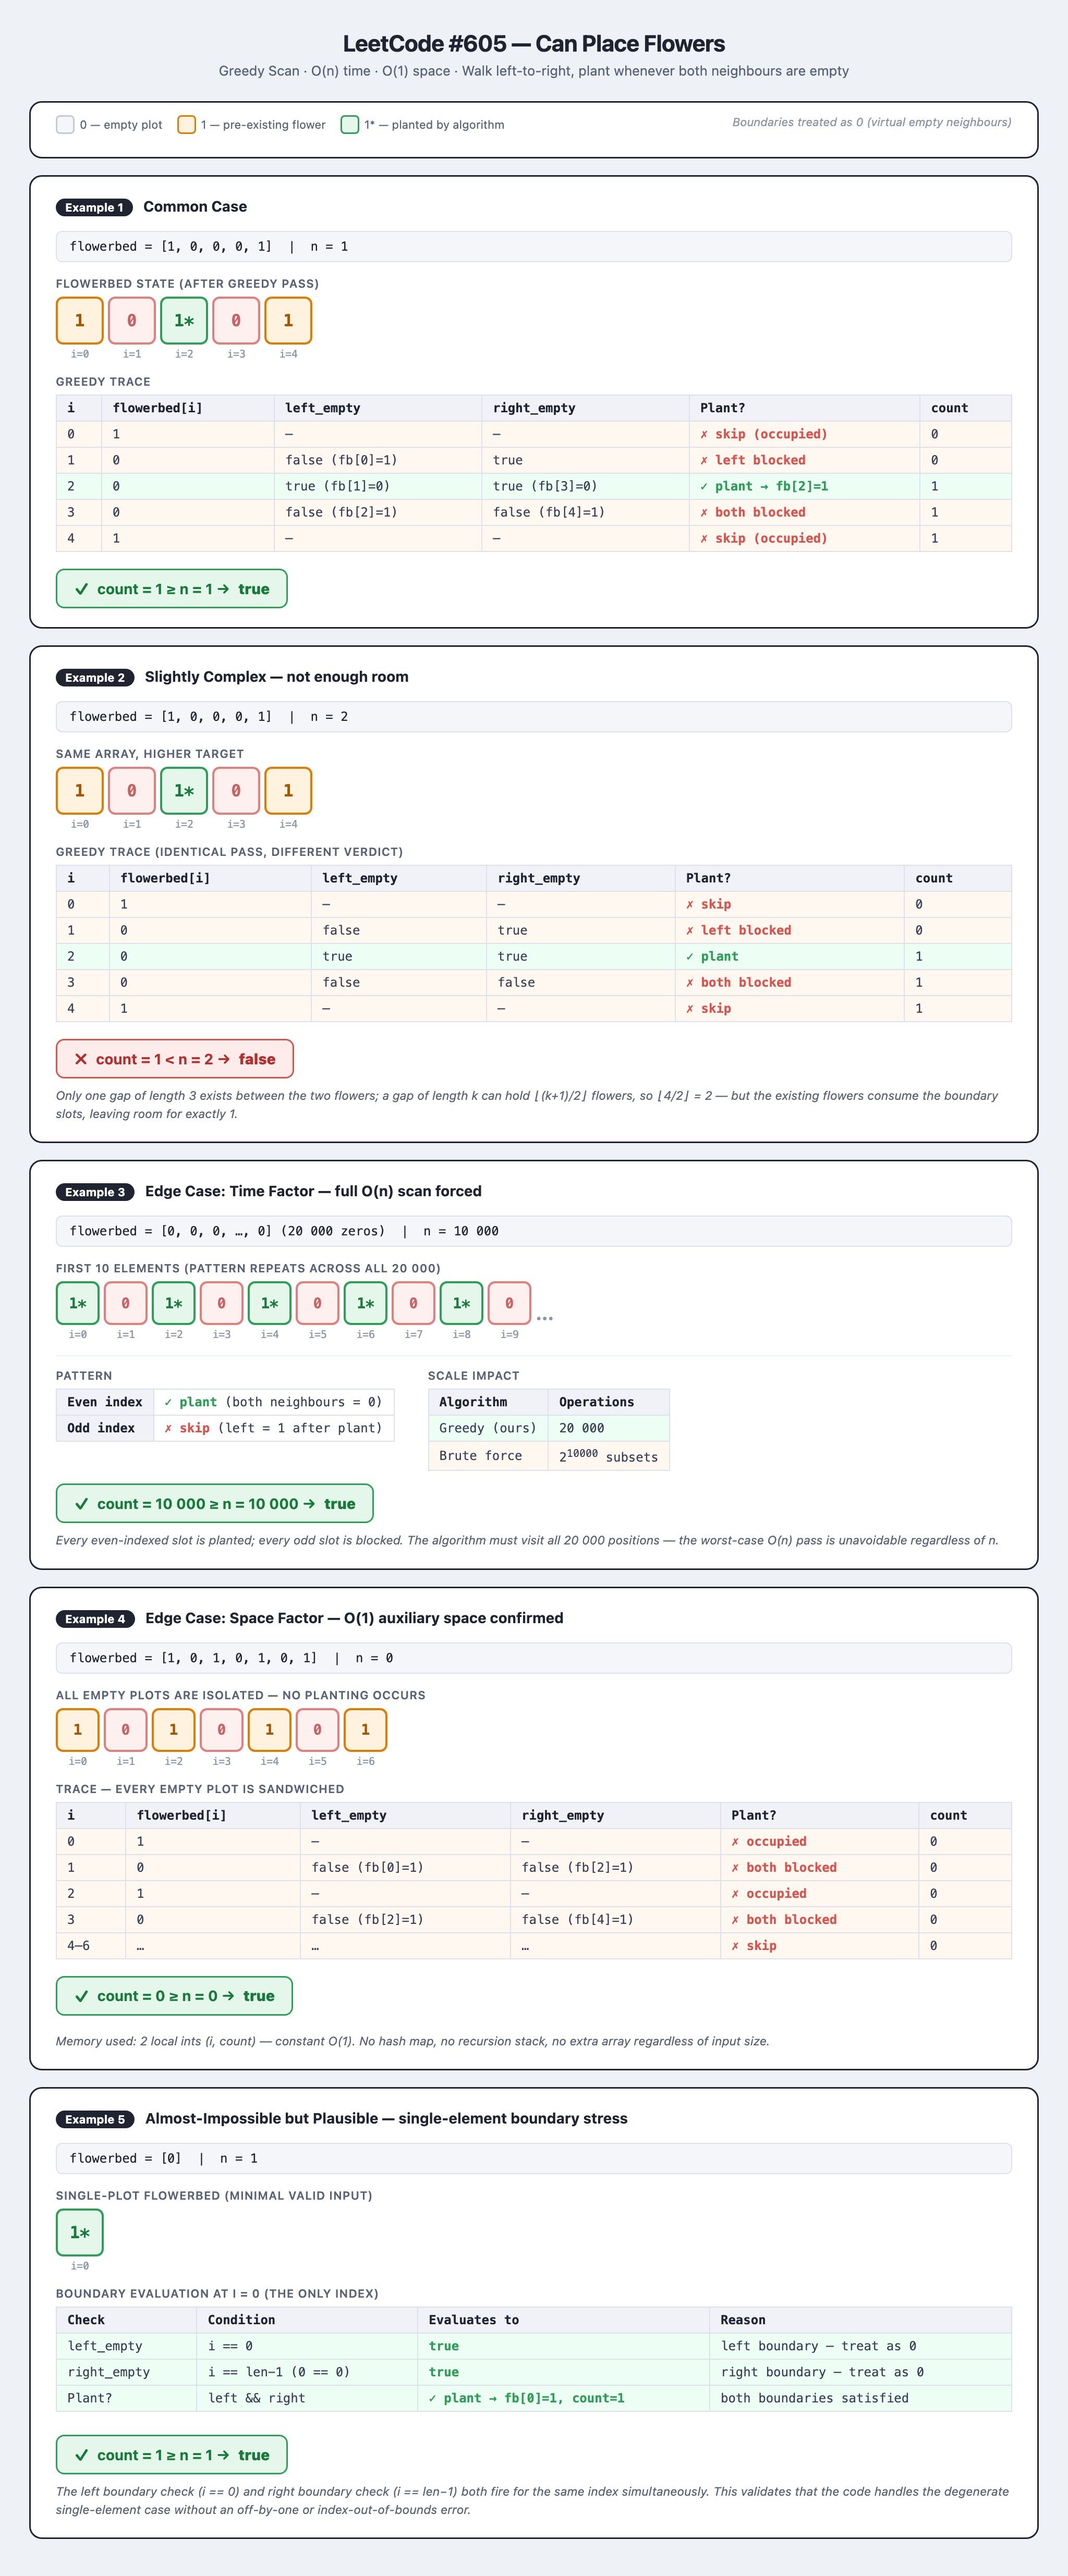